In [47]:
%matplotlib widget
# Boilerplate import code for all libraries
# Changes to the precision require re-loading the kernel and need to be done before any op uses them.
import warpSPHCore_config as swc
from typing import Any
swc.configure(precision="float32", dim=Any) # precision: float16|half|float32|single|float64|double

import warpSPHCore as sph
from warpSPHCore.type_config import *
print(get_type_config()) # confirms active settings

# Initialize warp at this point
import warp as wp; wp.init()

import os
import torch
if torch.cuda.is_available(): # set the TORCH_CUDA_ARCH_LIST environment variable to the compute capability of the GPU for faster compiles
    os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'

import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)
from tqdm.autonotebook import tqdm

# final import blocks that are generic
import matplotlib.pyplot as plt
from torch.profiler import profile, record_function, ProfilerActivity
import numpy as np
import math
import shlex    
import subprocess
import shutil

# custom SPH libraries
from warpSPHIntegrators.integration import *
from warpSPHCore import *
from warpSPHPlotting import *

# This library
from warpSPH import *

# The case utilities that contain all the case setup functions for the various test cases
from warpSPH.caseUtils import *

{'scalar_t': <class 'warp._src.types.float32'>, 'dim_t': typing.Any}


In [48]:
nx = 128
dim = 2
L = 2 * np.pi
n_h = 4
targetDt = 0.001

gamma = 5/3
rho0 = 1
nu_visc = 0.0005
freeSurface = False

extraData = {
    'nx': nx,
    'dim': dim,
    'L': L,
    'n_h': n_h,

    'gamma': gamma,
    'rho0': rho0,
    'nu_visc': nu_visc,
}

In [49]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = get_torch_precision()

domain = buildDomainDescription(L, dim, True, device, dtype)
domain.min = torch.zeros(dim, device=device, dtype=dtype)
domain.max = torch.ones(dim, device=device, dtype=dtype) * 2 * np.pi
interiorDomain = domain

config, integrator = buildConfig(
    domain = domain,
    dim = dim,
    kernel = KernelFunctions.Wendland2,
    targetNeighbors = n_h_to_nH(4, dim),
    supportMode = SupportScheme.KernelMeanSymmetric,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = None,
    adaptiveDt = True,
    cflFactor=0.3,
)
config.nx = nx

config.minDt = 1e-8
# config.dx = L / (nx * 2)

scheme = IncompressibleSPHScheme.divergenceFree
SimulationSystem, SimulationState, SimulationConfig, SimulationUpdate, fn, export_fn, import_fn = buildScheme(scheme)


schemeConfig = SimulationConfig()
schemeConfig.surfaceDetectionConfig.active = freeSurface


In [50]:

fluid_sdf = lambda x: sampleDomainSDF(x, domain, invert = True)
regions = []

regions.append(buildRegion(config, schemeConfig, fluid_sdf, RegionType.Fluid, initialConditions = {}))

for region in regions:
    region = filterRegion(region, regions)

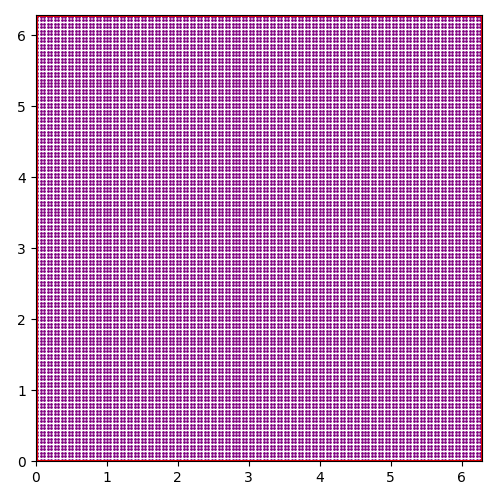

In [51]:
fig, axis = plt.subplots(1, 1, figsize=(5, 5), squeeze=False)
plotRegions(regions, axis[0,0], plotFluid = True, plotParticles = True)

rectangle = plt.Rectangle((domain.min[0].cpu().numpy(), domain.min[1].cpu().numpy()), domain.max[0].cpu().numpy() - domain.min[0].cpu().numpy(), domain.max[1].cpu().numpy() - domain.min[1].cpu().numpy(), fill=False, color='black', lw=2)
axis[0,0].add_patch(rectangle)

rectangleInterior = plt.Rectangle((interiorDomain.min[0].cpu().numpy(), interiorDomain.min[1].cpu().numpy()), interiorDomain.max[0].cpu().numpy() - interiorDomain.min[0].cpu().numpy(), interiorDomain.max[1].cpu().numpy() - interiorDomain.min[1].cpu().numpy(), fill=False, color='red', lw=2)
axis[0,0].add_patch(rectangleInterior)

import matplotlib.patches as patches

for ax in axis.flatten():
    ax.set_aspect('equal')
    ax.set_xlim(domain.min[0].item(), domain.max[0].item())
    ax.set_ylim(domain.min[1].item(), domain.max[1].item())

fig.tight_layout()

In [52]:
compressibleSystem = setupBasicWeaklyCompressibleInitialState(nx, config, schemeConfig, SimulationState, SimulationSystem)
densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"Initial density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")
compressibleSystem.state.masses = compressibleSystem.state.masses / densities.mean() * rho0
densities = computeDensities(compressibleSystem.state, config, schemeConfig, None)
print(f"After correction density stats: mean: {densities.mean().cpu().item():.6g}, min: {densities.min().cpu().item():.6g}, max: {densities.max().cpu().item():.6g}")

# compressibleSystem.state.positions = shuffleParticles(compressibleSystem.state, config, schemeConfig, 32, jitterAmount = 1.0)


k = 2
u_mag = 1
k_ = k

ktgv = k_ / 2
if k_ % 2 == 0:
    phaseShift_x = np.pi / 2# / k
    phaseShift_y = np.pi / 2# / k
else:
    phaseShift_x = 0
    phaseShift_y = 0

compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)



schemeConfig.fluid.fixedSoundSpeed, config.dt = setupWeaklyCompressibleTimestep(config, schemeConfig, compressibleSystem, targetDt, verbose = True)
print(f"Computed timestep: {config.dt:.6g}, target timestep: {targetDt:.6g}, diff: {abs(config.dt - targetDt):.6g}")

Initial density stats: mean: 1.00121, min: 1.0012, max: 1.00121
After correction density stats: mean: 1, min: 0.999994, max: 1
Computed c0: 31.045583724975586, target c0: 10.0, diff: 21.045583724975586
Computed dt: 0.0010000000474974513, target dt: 0.001, diff: 0.0
Max velocity: 0.9993979334831238, CFL: 0.020359566435217857, Max Mach: 0.032191306352615356
Computed timestep: 0.001, target timestep: 0.001, diff: 0


In [53]:
ke0 = compressibleSystem.state.masses * torch.linalg.norm(compressibleSystem.state.velocities, dim=1)**2 * 0.5
m_total = compressibleSystem.state.masses.sum().cpu().item()
# kineticEnergy = np.array([ke.cpu().item() for ke in kes]).sum()

domainL = config.domain.max[0].cpu().item() - config.domain.min[0].cpu().item()
Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2
print(f"Theoretical initial kinetic energy: {Ek0_theoretical:.6g}")
print(f"Initial kinetic energy from simulation: {ke0.sum().cpu().item():.6g}")
print(f'Difference: {abs(Ek0_theoretical - ke0.sum().cpu().item()):.6g}')

Theoretical initial kinetic energy: 9.8696
Initial kinetic energy from simulation: 9.85772
Difference: 0.0118893


In [54]:
runningState = compressibleSystem.initializeNewState()

caseName = 'random_incompressible'
exportPath = prepExport(f'{caseName}', config, schemeConfig, scheme, export_fn)
# exportSimulationSystem(exportPath, 'initialState', scheme, compressibleSystem, exportAdjacency = False, stages = None, exportStagesAdjacency = False, extraData = dict({
    # 'frame_num': 0,
# }, **extraData))

In [55]:
from dfsph import *

In [56]:
config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
# runningState.state.positions = shuffleParticles(runningState.state, config, schemeConfig, 0, jitterAmount = 0.01)
runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)


for i in tqdm(range(32)):

    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype),
            dt = config.dt
    )
    trajectories.append((errors,pressures))

    dx = config.dt**2 * a_p
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p #runningState.state.velocities


  0%|          | 0/32 [00:00<?, ?it/s]

Position update: mean: -7.21645e-15, min: -2.56278e-07, max: 1.97264e-07
Position update: mean: -6.43929e-15, min: -3.17052e-07, max: 3.22618e-07
Position update: mean: -1.42109e-14, min: -3.71746e-07, max: 3.25241e-07
Position update: mean: -1.22125e-14, min: -5.39241e-07, max: 3.40786e-07
Position update: mean: -1.85407e-14, min: -3.30296e-07, max: 3.61147e-07
Position update: mean: -1.11022e-14, min: -5.11011e-07, max: 3.30044e-07
Position update: mean: -1.64313e-14, min: -3.90216e-07, max: 3.59564e-07
Position update: mean: -1.24345e-14, min: -4.93725e-07, max: 3.55319e-07
Position update: mean: -1.63203e-14, min: -3.69338e-07, max: 3.57549e-07
Position update: mean: -1.22125e-14, min: -4.99192e-07, max: 3.21496e-07
Position update: mean: -1.43219e-14, min: -3.7393e-07, max: 3.68009e-07
Position update: mean: -1.31006e-14, min: -4.73986e-07, max: 3.62488e-07
Position update: mean: -1.32672e-14, min: -3.52116e-07, max: 3.56101e-07
Position update: mean: -1.11022e-14, min: -4.96236e-

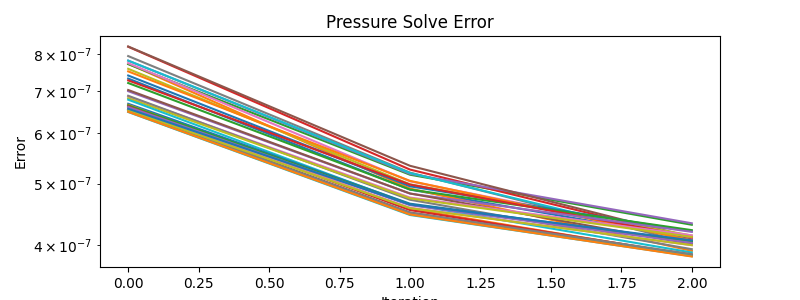

In [57]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3), squeeze=False)

for i, (errors, pressures) in enumerate(trajectories):
    axis[0,0].plot(errors, label=f"Trajectory {i+1}")
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")
axis[0,0].set_yscale('log')

In [58]:

markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.densities,
    },
    plotOptions = {
        "A": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = UniformColorMap.viridis,
            # flipColorMap=True,
            markerSize = markerSize,
            midPoint = 1.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "densities",
            # vMin = 0.99,
            # vMax = 1.01
            # gridVisualization = GridVisualization(
            #     resolution = 512,
            # ),
        ),
    },
    figTitle = "Wave Equation Example",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)


RFBOutputContext()

In [59]:
config.dt = 1e-3
runningState = compressibleSystem.initializeNewState()
runningState.state.positions = shuffleParticles(runningState.state, config, schemeConfig, 0, jitterAmount = 0.01)

runningState.state.velocities = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype)
adjacency = None

trajectories = []
adjacency = buildVerletList(
    runningState.state, 
    config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = adjacency,
    verbose = False)
rhoInit = computeDensities(runningState.state, config, schemeConfig, adjacency)

# schemeConfig.solverConfig.pressureSolver.tolerance = 1e-5


for i in (tq:=tqdm(range(16))):

    adjacency = buildVerletList(
        runningState.state, 
        config.domain, verletScale = 1.4, supportMode = SupportScheme.SuperSymmetric,
        priorNeighborhood = adjacency,
        verbose = False)
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, adjacency)
    runningState.state.pressures[:] = 0.0

    a_p, pressureB, errors, pressures = solveIncompressible(
            particles = runningState.state,
            config = config,
            schemeConfig = schemeConfig,
            adjacency = adjacency,
            dvdt = torch.zeros_like(runningState.state.velocities, device=config.device, dtype=config.dtype),
            dt = config.dt
    )
    trajectories.append((errors,pressures))

    dx = config.dt**2 * a_p
    print(f"Position update: mean: {dx.mean().cpu().item():.6g}, min: {dx.min().cpu().item():.6g}, max: {dx.max().cpu().item():.6g}")
    tq.set_description(f"Step {i+1}/{128}, iters: {len(errors)}, error: {errors[0]:.6g} -> {errors[-1]:.6g}, pressure min/max/mean: {pressures[-1]}")

    # runningState.state.velocities = runningState.state.velocities + config.dt * a_p
    runningState.state.positions = runningState.state.positions + config.dt * config.dt * a_p

schemeConfig.solverConfig.pressureSolver.tolerance = 5e-4

  0%|          | 0/16 [00:00<?, ?it/s]

Position update: mean: -4.3201e-12, min: -0.00354643, max: 0.00381836
Position update: mean: 1.47438e-13, min: -7.68393e-05, max: 7.62808e-05
Position update: mean: -2.55795e-13, min: -6.16657e-05, max: 6.81572e-05
Position update: mean: 1.84741e-13, min: -5.35291e-05, max: 6.51265e-05
Position update: mean: -1.06581e-13, min: -4.96003e-05, max: 6.0613e-05
Position update: mean: -2.91323e-13, min: -4.68478e-05, max: 5.69702e-05
Position update: mean: -3.41061e-13, min: -4.5227e-05, max: 5.35299e-05
Position update: mean: -7.4607e-14, min: -4.35944e-05, max: 5.05008e-05
Position update: mean: 4.61853e-14, min: -4.20013e-05, max: 4.77631e-05
Position update: mean: -1.42109e-13, min: -4.04253e-05, max: 4.52435e-05
Position update: mean: -2.0961e-13, min: -3.88978e-05, max: 4.28801e-05
Position update: mean: -1.03029e-13, min: -3.74342e-05, max: 4.06946e-05
Position update: mean: -6.21725e-14, min: -3.60405e-05, max: 3.87698e-05
Position update: mean: 1.04805e-13, min: -3.46845e-05, max: 3

Text(0, 0.5, 'Error')

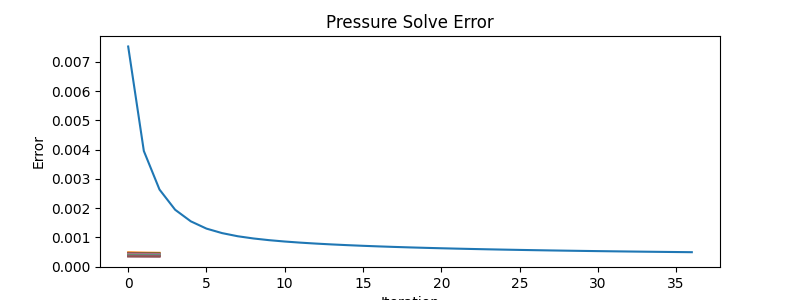

In [60]:
fig, axis = plt.subplots(1, 1, figsize=(8, 3), squeeze=False)

for i, (errors, pressures) in enumerate(trajectories):
    axis[0,0].plot(errors, label=f"Trajectory {i+1}")
axis[0,0].set_title("Pressure Solve Error")
axis[0,0].set_xlabel("Iteration")
axis[0,0].set_ylabel("Error")
# axis[0,0].set_yscale('log')

In [61]:
compressibleSystem.state.positions = runningState.state.positions.clone()
# compressibleSystem.state.velocities[:,0] =  u_mag * torch.cos(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.sin(ktgv *  compressibleSystem.state.positions[:,1] + phaseShift_y)
# compressibleSystem.state.velocities[:,1] = -u_mag * torch.sin(ktgv * compressibleSystem.state.positions[:,0] + phaseShift_x) * torch.cos(ktgv * compressibleSystem.state.positions[:,1] + phaseShift_y)

octaves = 3
lacunarity = 2
persistence = 0.5
baseFrequency = 2
tileable = True
kind = 'perlin'
seed = 45906734
obstacle = False
schemeConfig.regions = []
config.regions = []


velocities = sampleDivergenceFreeNoise(compressibleSystem.state, domain, config, schemeConfig, nx * 2, 
                                    octaves = octaves, lacunarity = lacunarity, persistence = persistence, baseFrequency = baseFrequency, tileable = tileable, kind = kind, seed = seed)
compressibleSystem.state.velocities[:] = velocities


In [62]:

hMin = compressibleSystem.state.supports.min().cpu().item()
vMax = torch.linalg.norm(compressibleSystem.state.velocities, dim = -1).max().cpu().item()
velocityRatio = hMin / vMax
cflNumber = config.dt / velocityRatio


print(f"Initial hMin: {hMin:.6g}, vMax: {vMax:.6g}, CFL number: {cflNumber:.6g}")


Initial hMin: 0.19635, vMax: 1, CFL number: 0.00509296


In [63]:
display(schemeConfig.surfaceDetectionConfig)

SurfaceDetectionConfig(active=False, colorFieldThreshold=0.75, colorFieldGradThreshold=10.0, barecascoThreshold=1.0471975511965976, expansionIterations=1, scheme=<SurfaceDetectionScheme.Barecasco: 2>, normalSource=<NormalSource.LambdaGrad: 2>)

In [64]:
runningState = compressibleSystem.initializeNewState()

runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)
# runningState.state.densities[:] = schemeConfig.fluid.restDensity

print(f"Initial densities: mean: {runningState.state.densities.mean().cpu().item():.6g}, min: {runningState.state.densities.min().cpu().item():.6g}, max: {runningState.state.densities.max().cpu().item():.6g}")

result = integrator.function(
    state = runningState,
    f = dfsph_step,
    dt = config.dt,  
    config = config,
    schemeConfig = schemeConfig,
    verbose = False,
    # priorStep = priorStep
)

Initial densities: mean: 1.00008, min: 0.998242, max: 1.00169


In [65]:
errors, pressures = result.stages[-1].aux[-2]
numIters = len(errors)
print(f"Final pressure solve: error: {errors[-1]:.6g}, pressure min/max/mean: {pressures[-1]}, iterations: {numIters}")
errors_incomp, pressures_incomp = result.stages[-1].aux[-1]
numIters_incomp = len(errors_incomp)
print(f"Final incompressible pressure solve: error: {errors_incomp[-1]:.6g}, pressure min/max/mean: {pressures_incomp[-1]}, iterations: {numIters_incomp}")

Final pressure solve: error: 0.0024884, pressure min/max/mean: (-1.2269139289855957, 1.407165288925171, 3.4924596548080444e-10), iterations: 5
Final incompressible pressure solve: error: 0.000343045, pressure min/max/mean: (-65.87686157226562, 64.07164764404297, 3.053699254989624), iterations: 3


In [66]:
runningState.state.pressures.min(), runningState.state.pressures.max(), runningState.state.pressures.mean()

(tensor(0., device='cuda:0'),
 tensor(0., device='cuda:0'),
 tensor(0., device='cuda:0'))

In [70]:

markerSize = 8
plotter = visualize(
    particleState = runningState.state,
    domain = config.domain,
    quantities = {
        "A": runningState.state.velocities,
        "B":runningState.state.pressures,# - runningState.state.pressures.median(),
    },
    plotOptions = {
        "A": PlottingOptions(
            # colorMap = DivergingColorMap.RdBu,
            # flipColorMap=True,
            colorMap = UniformColorMap.viridis,
            markerSize = markerSize,
            midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            mapping = Mapping.L2Norm,
            plotTitle = "velocities",
            gridVisualization = GridVisualization(
                resolution = 512,
            ),
            # vMin=1e-10
        ),
        "B": PlottingOptions(
            colorMap = DivergingColorMap.RdBu,
            flipColorMap=True,
            markerSize = markerSize,
            # midPoint = 0.0,
            quantityScaling = PlotScaling.Linear,
            plotTitle = "pressures",
            # vMin = 0.99,
            # vMax = 1.01
            gridVisualization = GridVisualization(
                resolution = 512,
            ),
        ),
    },
    figTitle = f"Taylor Green Vortex (Incompressible), t={runningState.t:.3f}s ptcls={runningState.state.positions.shape[0]}, dt={config.dt:.3g}s\nDivergence Free error={errors[0]:.4g}->{errors_incomp[-1]:.4g} after {numIters} iterations, Incompressible error={errors_incomp[0]:.4g}->{errors_incomp[-1]:.4g} after {numIters_incomp} iterations",
    mosaic = 'AB',
    figsize= (11,5),
    backend='vispy',
    # backend='pyVista',
    # backendOptions = {
    #     # In notebooks, use trame for reliable live updates.
    #     'jupyter_backend': 'trame',
    # }
)
imagePath = f'{exportPath}/images'
os.makedirs(imagePath, exist_ok = True)
plotter.export(f'{imagePath}/frame_00000.png', dpi = 300)




RFBOutputContext()

Module warpSPHCore.operations_grid.wp_interpolate_grid 71cb703 load on device 'cuda:0' took 11.83 ms  (cached)


In [71]:
meanRhoError = (runningState.state.densities - schemeConfig.fluid.restDensity).abs().mean().cpu().item()
print(f"Mean density error: {meanRhoError:.6g}")

Mean density error: 0.000348747


In [72]:
schemeConfig.diffusionParams.inviscid = False
schemeConfig.diffusionParams.viscidNu = 0.01
schemeConfig.shiftProperties.active = False

In [73]:
config.dt = 1e-3

t_limit = 10.0
nSteps = int(t_limit / config.dt)
# nSteps = 7

runningState = compressibleSystem.initializeNewState()

kes = []
priorStep = None
for i in (tq := tqdm(range(nSteps), leave = False)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = dfsph_step,
        dt = config.dt,  
        config = config,
        schemeConfig = schemeConfig,
        verbose = False,
        # priorStep = priorStep
    )
    kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
    # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    # runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)
    # print(f'Computing with verletScale = 1.0')
    # adjacency = buildVerletList(
    #         runningState.state, 
    #         config.domain, verletScale = 1.0, supportMode = SupportScheme.SuperSymmetric,
    #         priorNeighborhood = None,
    #         verbose = False)
    # numNeighbors = adjacency.numNeighbors
    # print(f'{i}: Min neighbors: {numNeighbors.min().cpu().item()}, Max neighbors: {numNeighbors.max().cpu().item()}, Mean neighbors: {numNeighbors.float().mean().cpu().item()}')
    runningState.state.densities = computeDensities(runningState.state, config, schemeConfig, None)

    # print(f'{i}: Min Density [no adj]: {runningState.state.densities.min().cpu().item()}, Max Density: {runningState.state.densities.max().cpu().item()}, Mean Density: {runningState.state.densities.mean().cpu().item()}')

    # densitiesAdj = computeDensities(runningState.state, config, schemeConfig, adjacency)

    # print(f'Computing with verletScale = {config.verletScale}')
    # adjacency2 = buildVerletList(
    #         runningState.state, 
    #         config.domain, verletScale = config.verletScale, supportMode = SupportScheme.SuperSymmetric,
    #         priorNeighborhood = None,
    #         verbose = False)
    # numNeighbors = adjacency2.numNeighbors
    # densitiesAdj2 = computeDensities(runningState.state, config, schemeConfig, adjacency2)
    # print(f'{i}: Min neighbors: {numNeighbors.min().cpu().item()}, Max neighbors: {numNeighbors.max().cpu().item()}, Mean neighbors: {numNeighbors.float().mean().cpu().item()}')

    # diff = torch.abs(densitiesAdj - densitiesAdj2)
    # maxDiff = diff.max().cpu().item()
    # meanDiff = diff.mean().cpu().item()
    # print(f'{i}: Min Density [adj]: {densitiesAdj.min().cpu().item()}, Max Density: {densitiesAdj.max().cpu().item()}, Mean Density: {densitiesAdj.mean().cpu().item()}, Max Diff: {maxDiff:.6g}, Mean Diff: {meanDiff:.6g}')

    # diffNumNeighbors = torch.abs(adjacency.numNeighbors - adjacency2.numNeighbors)
    # maxDiffNeighbors = diffNumNeighbors.max().cpu().item()
    # meanDiffNeighbors = diffNumNeighbors.float().mean().cpu().item()
    # print(f'{i}: Min Neighbors [adj]: {adjacency.numNeighbors.min().cpu().item()}, Max Neighbors: {adjacency.numNeighbors.max().cpu().item()}, Mean Neighbors: {adjacency.numNeighbors.float().mean().cpu().item()}, Max Diff Neighbors: {maxDiffNeighbors:.6g}, Mean Diff Neighbors: {meanDiffNeighbors:.6g}')

    # if maxDiff > 1e-3:
    #     print(f"Warning: Density difference between adjacency computations exceeds threshold at step {i}. Max Diff: {maxDiff:.6g}, Mean Diff: {meanDiff:.6g}")
    #     break

    # print(f'{i}: Min Density [adj]: {runningState.state.densities.min().cpu().item()}, Max Density: {runningState.state.densities.max().cpu().item()}, Mean Density: {runningState.state.densities.mean().cpu().item()}')

    errors, pressures = result.stages[-1].aux[-2]
    numIters = len(errors)
    errors_incomp, pressures_incomp = result.stages[-1].aux[-1]
    numIters_incomp = len(errors_incomp)
    if i % 10 == 0 and i > 0:
        plotter.updateQuantities(
            {
                "A": runningState.state.velocities,
                # "A": runningState.state.densities,
                "B": runningState.state.pressures - runningState.state.pressures.mean(),
                # "B": runningState.state.densities,
            },
            newParticleState = runningState.state,
        )
        plotter.export(f'{imagePath}/frame_{i:05d}.png', dpi = 300)


        plotter.updateTitle(f'Taylor Green Vortex (Incompressible), t={(i+1)*config.dt:.3f}s ptcls={runningState.state.positions.shape[0]}, dt={config.dt:.3g}s\nDivergence Free error={errors[0]:.4g}->{errors[-1]:.4g} after {numIters} iterations, Incompressible error={errors_incomp[0]:.4g}->{errors_incomp[-1]:.4g} after {numIters_incomp} iterations')
    # break
        
    maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms div free {errors[0]:.4g}->{errors[-1]:.4g} in {numIters} iters, incompressible {errors_incomp[0]:.4g}->{errors_incomp[-1]:.4g} in {numIters_incomp} iters")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break
    if torch.any(torch.isnan(runningState.state.velocities)):
        print("NaN detected in velocities, stopping simulation.")
        break



  0%|          | 0/10000 [00:00<?, ?it/s]

In [45]:
rho = computeDensities(runningState.state, config, schemeConfig, None)
meanRhoError = (rho - schemeConfig.fluid.restDensity).abs().mean().cpu().item()
print(f"Mean density error: {meanRhoError:.6g}")

Mean density error: 0.000499948


In [74]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 60 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

'export/random_incompressible/output.mp4'

In [30]:
runningState.state.densities.min(), runningState.state.densities.max(), runningState.state.densities.mean()

(tensor(0.9992, device='cuda:0'),
 tensor(1.0016, device='cuda:0'),
 tensor(1.0005, device='cuda:0'))

Something to note here is that the effective viscosity we measure here will be about half of the defined viscosity. This is an effect of the classic monaghan viscosity that only applies the viscosity to particles approaching each other. This is only true for (approximately) half the particles, thus we measure a viscosity that is half as well.

In [58]:
ts = np.arange(len(kes)) * config.dt#.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])
E_k0 = kineticEnergy[0]

# Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
mask = (ts > 0) & (kineticEnergy > 0)
slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
nu_eff = -slope / (4 * ktgv**2)
print(f"Estimated effective viscosity: {nu_eff:.6g}, actual viscosity: {schemeConfig.diffusionParams.viscidNu
:.6g}, diff: {abs(nu_eff - schemeConfig.diffusionParams.viscidNu
):.6g}")

Estimated effective viscosity: 0.00612538, actual viscosity: 0.01, diff: 0.00387462


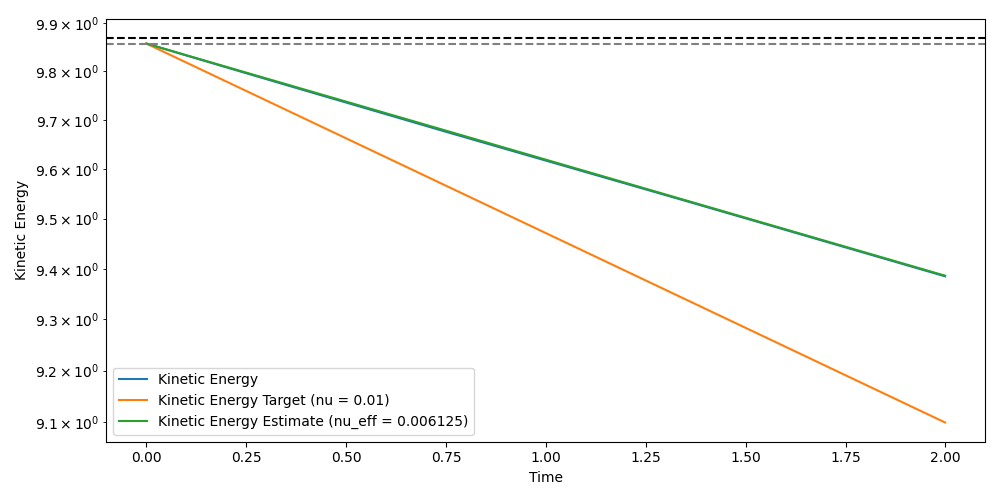

In [60]:
fig, axis = plt.subplots(1, 1, figsize=(10, 5), squeeze=False)

ts = np.arange(len(kes)) * config.dt#.cpu().item()
kineticEnergy = np.array([ke.cpu().item() for ke in kes])

nu = schemeConfig.diffusionParams.viscidNu

Ek0_theoretical = 0.25 * u_mag**2 * schemeConfig.fluid.restDensity * domainL**2
ke0 = E_k0
# For u ~ exp(-2*nu*k_mode^2*t), kinetic energy decays as exp(-4*nu*k_mode^2*t).
E_kestimate = ke0 * np.exp(-4 * ts * (ktgv**2) * nu_eff)
E_ktarget = ke0 * np.exp(-4 * ts * (ktgv**2) * nu)

axis[0,0].plot(ts, kineticEnergy, label='Kinetic Energy')
axis[0,0].plot(ts, E_ktarget, label=f'Kinetic Energy Target (nu = {nu:.4g})')
axis[0,0].plot(ts, E_kestimate, label=f'Kinetic Energy Estimate (nu_eff = {nu_eff:.4g})')
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Kinetic Energy')
axis[0,0].legend()

axis[0,0].axhline(Ek0_theoretical, color='black', linestyle='--', label='Theoretical Initial Kinetic Energy')
axis[0,0].axhline(ke0, color='gray', linestyle='--', label='Initial Kinetic Energy from Simulation')

axis[0,0].set_yscale('log')

fig.tight_layout()

In [33]:
# exportSimulationSystem(exportPath, f'finalState', scheme, runningState, exportAdjacency = False, stages = result.stages, exportStagesAdjacency = True, extraData = dict(**extraData, **{
#     'kineticEnergy': kineticEnergy,
#     'thermalEnergy': thermalEnergy,
#     'totalEnergy': totalEnergy,
#     'frame_num': i,
# }))

In [ ]:
ffmpeg_cmd = "ffmpeg -y -loglevel error -hide_banner -framerate 50 -f image2 -pattern_type glob -i 'frame_*.png' -c:v libx264 -pix_fmt yuv420p -b:v 10M output.mp4"
subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4  -vf "fps=50,scale=540:-1:flags=lanczos,palettegen" palette.png'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)
# ffmpeg_cmd = 'ffmpeg -y -loglevel error -hide_banner -i output.mp4 -i palette.png -filter_complex "fps=25,scale=540:-1:flags=lanczos[x];[x][1:v]paletteuse" out.gif'
# subprocess.run(shlex.split(ffmpeg_cmd), check=True, cwd = imagePath)

# # now copy the output.mp4 and out.gif to the parent directory for easier access
shutil.copy(f'{imagePath}/output.mp4', f'{exportPath}/output.mp4')
# shutil.copy(f'{imagePath}/out.gif', f'{exportPath}/out.gif');

We can run a convergence test to see how the viscosity scales as well:

In [43]:
nu_tests = np.logspace(-1, -5, base=10, num=10)
test_data = []

for nu in tqdm(nu_tests, desc="Testing viscosities", leave=False):
    t_limit = 2.0
    nSteps = int(t_limit / config.dt)

    runningState = compressibleSystem.initializeNewState()
    schemeConfig.diffusionParams.viscidNu = nu

    kes = []
    priorStep = None
    for i in (tq := tqdm(range(nSteps), leave = False)):
        begin = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)
        begin.record()
        result = integrator.function(
            state = runningState,
            f = fn,
            dt = config.dt,  
            config = config,
            schemeConfig = schemeConfig,
            verbose = False,
            priorStep = priorStep
        )
        kes.append(torch.sum(0.5 * result.state.state.masses * torch.sum(result.state.state.velocities**2, dim=1)))
        # print('max_vel:', torch.linalg.norm(result.state.state.velocities, dim = -1).max())
        end.record()
        torch.cuda.synchronize()
        priorStep = result.stages[-1]
        timing = begin.elapsed_time(end)

        runningState = result.state

        if i % 60 == 0 and i > 0:
            plotter.updateQuantities(
                {
                    "A": runningState.state.velocities,
                    "B": runningState.state.densities,
                },
                newParticleState = runningState.state,
            )
            
        maxVel = torch.linalg.norm(runningState.state.velocities, dim = -1).max()
        tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g} | max vel: {maxVel:.3g} | iter time: {timing:.3f} ms")
        # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
        # break
        if torch.any(torch.isnan(runningState.state.velocities)):
            print("NaN detected in velocities, stopping simulation.")
            breakts = np.arange(len(kes)) * config.dt.cpu().item()
    kineticEnergy = np.array([ke.cpu().item() for ke in kes])
    E_k0 = kineticEnergy[0]

    # Fit an effective viscosity from d/dt log(E_k) = -4 * (ktgv**2) * nu_eff
    mask = (ts > 0) & (kineticEnergy > 0)
    slope = np.polyfit(ts[mask], np.log(kineticEnergy[mask] / E_k0), 1)[0]
    nu_eff = -slope / (4 * ktgv**2)

    test_data.append({
        'nu': nu,
        'nu_eff': nu_eff,
        'nu_diff': abs(nu_eff - nu),
        'nu_rel_diff': abs(nu_eff - nu) / nu,
        'E_k0': E_k0,
        'kineticEnergy': kineticEnergy,
        'ts': ts,
    })


Testing viscosities:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

...

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

  0%|          | 0/1999 [00:00<?, ?it/s]

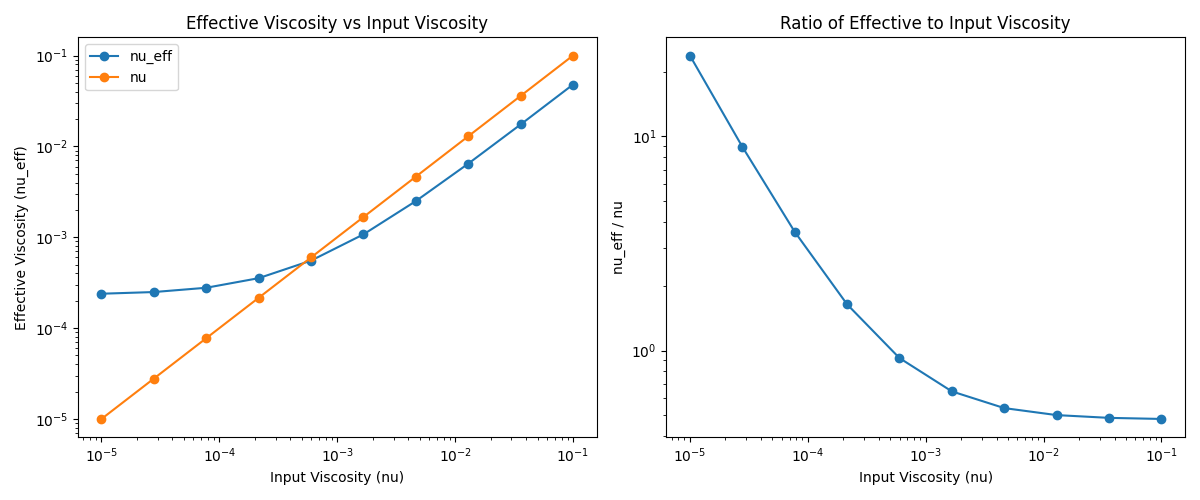

In [45]:
fig, axis = plt.subplots(1, 2, figsize=(12, 5), squeeze=False)

nus = np.array([data['nu'] for data in test_data])
nu_effs = np.array([data['nu_eff'] for data in test_data])
axis[0,0].loglog(nus, nu_effs, marker='o', label='nu_eff')
axis[0,0].loglog(nus, nus, marker='o', label='nu')
axis[0,0].set_xlabel('Input Viscosity (nu)')
axis[0,0].set_ylabel('Effective Viscosity (nu_eff)')
axis[0,0].set_title('Effective Viscosity vs Input Viscosity')
axis[0,0].legend()

axis[0,1].loglog(nus, nu_effs / nus, marker='o')
axis[0,1].set_xlabel('Input Viscosity (nu)')
axis[0,1].set_ylabel('nu_eff / nu')
axis[0,1].set_title('Ratio of Effective to Input Viscosity')

fig.tight_layout()

fig.savefig('nu_eff_vs_nu.png', dpi=300)
